## Présentation projet APR : Prédiction du joueur gagant sur le jeu mobile "Clash Royale", en fonction des données d'avant combat
Par Roxane CARON, Jérémy CHAZE et Paul BELLAN

## Imports

In [172]:
# Manipulation de données
import pandas as pd                    # DataFrames et analyse de données
import numpy as np                     # Calculs numériques et arrays
import random

# Visualisation
import matplotlib.pyplot as plt        # Graphiques de base
import seaborn as sns                  # Visualisations statistiques

# Modèles et algorithmes sklearn
from sklearn.ensemble import *         # RandomForest, GradientBoosting, AdaBoost
from sklearn.linear_model import *     # Régression linéaire, logistique, Ridge, Lasso
from sklearn.tree import *             # Arbres de décision
from sklearn.model_selection import *  # train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import *          # Métriques d'évaluation
from sklearn.preprocessing import StandardScaler  # Normalisation des données

# XGBoost - Gradient boosting optimisé, très performant
from xgboost import *                  # Tous les modèles XGBoost

# Imblearn - Gestion datasets déséquilibrés
from imblearn.under_sampling import RandomUnderSampler  # Sous-échantillonnage

# Deep Learning
import tensorflow as tf               # Framework de deep learning
from tensorflow.keras.models import Sequential    # Modèles séquentiels
from tensorflow.keras.layers import Dense         # Couches denses



## Lecture fichier csv

In [173]:
# Chargement des données Clash Royale
df = pd.read_csv(
    "/Users/jeremychaze/Documents/boulot/Centrale/Cours/S6/APR/file rouge/dataset_clash_royal.csv", 
    nrows = 10000  # Limite à 10000 lignes pour tests/prototypage rapide
)

In [174]:
# Exploration initiale du dataset        
print("\n=== PREMIERES LIGNES DU DATASET ===")
display(df.head()) # Dataset complet : 11 millions de lignes, échantillon actuel : 10 000

print("\n=== INFORMATIONS SUR LES COLONNES ===") 
display(df.info())

print("\n=== STATISTIQUES DESCRIPTIVES ===")
display(df.describe())


=== PREMIERES LIGNES DU DATASET ===


,Unnamed: 0,player1.totalcard.level,player1.troop.count,player1.structure.count,player1.spell.count,player1.common.count,player1.rare.count,player1.epic.count,player1.legendary.count,player1.elixir.average,...,player1.card8.id,player2.card1.id,player2.card2.id,player2.card3.id,player2.card4.id,player2.card5.id,player2.card6.id,player2.card7.id,player2.card8.id,player_1_win
0,840943,100,4,1,3,3,4,0,1,2.875,...,26000000,28000011,28000000,26000056,28000004,26000000,27000004,26000010,28000011,0
1,214752,104,4,2,2,0,2,5,1,4.500,...,28000015,26000009,26000023,26000015,26000027,26000048,28000007,28000015,28000012,1
2,1086322,82,5,0,3,3,1,2,2,3.875,...,26000037,26000020,26000033,26000011,26000005,28000005,28000011,26000012,26000042,1
3,60990,104,5,1,2,2,2,2,2,4.000,...,28000011,27000010,26000007,26000042,26000011,28000000,26000012,26000035,27000010,0
4,511145,103,7,0,1,1,3,2,2,4.500,...,26000037,26000014,26000000,28000004,26000021,28000008,26000041,26000011,27000006,1



=== INFORMATIONS SUR LES COLONNES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                10000 non-null  int64  
 1   player1.totalcard.level   10000 non-null  int64  
 2   player1.troop.count       10000 non-null  int64  
 3   player1.structure.count   10000 non-null  int64  
 4   player1.spell.count       10000 non-null  int64  
 5   player1.common.count      10000 non-null  int64  
 6   player1.rare.count        10000 non-null  int64  
 7   player1.epic.count        10000 non-null  int64  
 8   player1.legendary.count   10000 non-null  int64  
 9   player1.elixir.average    10000 non-null  float64
 10  player2.totalcard.level   10000 non-null  int64  
 11  player2.troop.count       10000 non-null  int64  
 12  player2.structure.count   10000 non-null  int64  
 13  player2.spell.count    

None


=== STATISTIQUES DESCRIPTIVES ===


,Unnamed: 0,player1.totalcard.level,player1.troop.count,player1.structure.count,player1.spell.count,player1.common.count,player1.rare.count,player1.epic.count,player1.legendary.count,player1.elixir.average,...,player1.card8.id,player2.card1.id,player2.card2.id,player2.card3.id,player2.card4.id,player2.card5.id,player2.card6.id,player2.card7.id,player2.card8.id,player_1_win
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000
mean,5.481128e+05,95.195200,5.578700,0.433500,1.987800,2.064600,2.019800,2.286800,1.628800,3.823507,...,2.669932e+07,2.641752e+07,2.644892e+07,2.651272e+07,2.661872e+07,2.653952e+07,2.655182e+07,2.662542e+07,2.668492e+07,0.505400
std,3.211428e+05,13.072214,1.100421,0.590773,0.884607,1.297843,1.251864,1.416385,1.208204,0.517379,...,9.273333e+05,7.830982e+05,8.052575e+05,8.432638e+05,8.944116e+05,8.532853e+05,8.621917e+05,8.949512e+05,9.206944e+05,0.499996
min,1.400000e+01,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.553571,...,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,2.600000e+07,0.000000
25%,2.710075e+05,90.000000,5.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.500000,...,2.600002e+07,2.600001e+07,2.600002e+07,2.600002e+07,2.600002e+07,2.600002e+07,2.600002e+07,2.600002e+07,2.600002e+07,0.000000
50%,5.436845e+05,102.000000,6.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.875000,...,2.600005e+07,2.600003e+07,2.600004e+07,2.600004e+07,2.600004e+07,2.600004e+07,2.600004e+07,2.600004e+07,2.600005e+07,1.000000
75%,8.240468e+05,104.000000,6.000000,1.000000,3.000000,3.000000,3.000000,3.000000,2.000000,4.125000,...,2.800000e+07,2.600007e+07,2.600008e+07,2.700001e+07,2.800000e+07,2.700001e+07,2.700001e+07,2.800000e+07,2.800000e+07,1.000000
max,1.105890e+06,104.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,8.000000,6.250000,...,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,2.800002e+07,1.000000


## Séparation des données

In [175]:
# Préparation des données pour l'apprentissage supervisé

# Variable cible : prédiction de victoire du joueur 1
y = df['player_1_win']  # Variable binaire (0/1) à prédire

# Variables explicatives : toutes les autres colonnes
X = df.drop(["player_1_win"], axis=1)  # Suppression de la cible des features

# Division train/test : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Pas de random_state défini : division aléatoire à chaque exécution

## On utilise des modèles déjà existants pour classifier l'importance des caractéristiques

On trouve une accuracy de 0.581 avec le modèle de classification Gradient Boosting


Text(0.5, 1.0, 'Importance des caractéristiques')

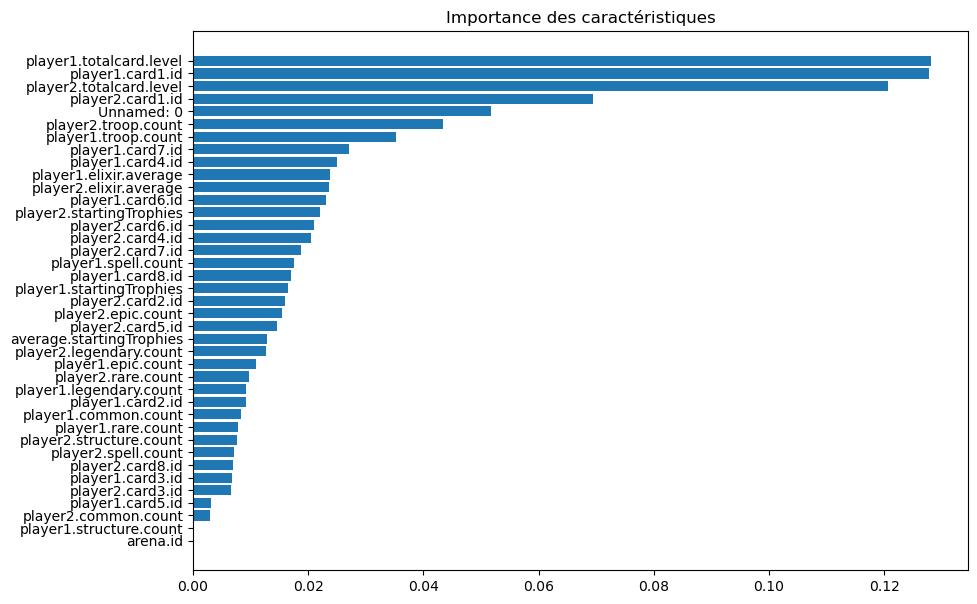

In [176]:
# Modèle de classification : Gradient Boosting
model1 = GradientBoostingClassifier()  # Paramètres par défaut
model1.fit(X_train, y_train)           # Entraînement sur les données d'apprentissage

# Prédiction et évaluation
y_hat = model1.predict(X_test)         # Prédictions sur le set de test
print("On trouve une accuracy de", accuracy_score(y_test, y_hat), "avec le modèle de classification Gradient Boosting")   # Affichage de la précision globale

# Analyse de l'importance des variables
importances = model1.feature_importances_  # Scores d'importance de chaque feature
indices = np.argsort(importances)          # Tri croissant des indices par importance

# Visualisation des features les plus importantes
plt.figure(figsize=(10,7))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title('Importance des caractéristiques')
# Graphique : variables les moins importantes en bas, plus importantes en haut

On trouve une accuracy de 0.6515 avec le modèle de classification XGBoost


Text(0.5, 1.0, 'Importance des caractéristiques')

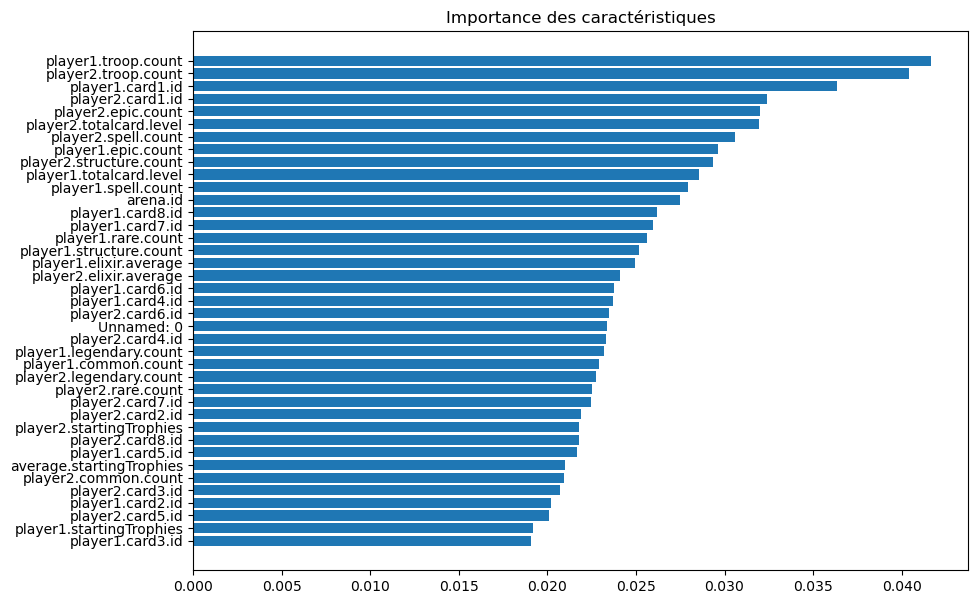

In [177]:
# Modèle XGBoost
model1 = XGBClassifier()  # Modèle XGBoost avec paramètres par défaut
model1.fit(X_train, y_train)  # Entraînement sur les données d'apprentissage

# Prédiction et évaluation
y_hat = model1.predict(X_test)  # Prédictions sur le jeu de test
print("On trouve une accuracy de", accuracy_score(y_test, y_hat), "avec le modèle de classification XGBoost")  # Affichage de la précision

# Analyse des variables importantes
importances = model1.feature_importances_  # Récupération des importances des variables
indices = np.argsort(importances)  # Tri par importance croissante

# Visualisation
plt.figure(figsize=(10,7))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title('Importance des caractéristiques')

## Test avec un MLP (Multi-Layer Perceptron)

In [178]:
# Normalisation des données
scaler = StandardScaler()  # Créateur de normalisation standard (z-score)
X = scaler.fit_transform(X)  # Pour que les données soient centrées autour de 0

In [179]:
# Division des données normalisées
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

# Architecture du réseau de neurones
model = Sequential()

# Couches cachées avec fonction d'activation ReLU
# ReLU est linéaire pour les valeurs positives et non linéaire (plate à zéro) pour les valeurs négatives
model.add(Dense(100, activation="relu"))
model.add(Dense(50, activation="relu"))
model.add(Dense(25, activation="relu"))

# Couche de sortie pour classification binaire
# transforme un vecteur de scores (ou de logits) en une distribution de probabilité sur plusieurs classes
model.add(Dense(1, activation='sigmoid'))

# Compilation du modèle
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entraînement
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=1)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5304 - loss: 0.6956 - val_accuracy: 0.5650 - val_loss: 0.6712
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.6412 - loss: 0.6286 - val_accuracy: 0.6840 - val_loss: 0.5313
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.7437 - loss: 0.4717 - val_accuracy: 0.7040 - val_loss: 0.4722
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - accuracy: 0.7527 - loss: 0.4267 - val_accuracy: 0.7035 - val_loss: 0.4651
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.7814 - loss: 0.4014 - val_accuracy: 0.7185 - val_loss: 0.4649
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - accuracy: 0.7947 - loss: 0.3829 - val_accuracy: 0.7070 - val_loss: 0.4643
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.8184 - loss: 0.3690 - val_accuracy: 0.7085 - val_loss: 0.4801
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8243 - loss: 0.3497 - va

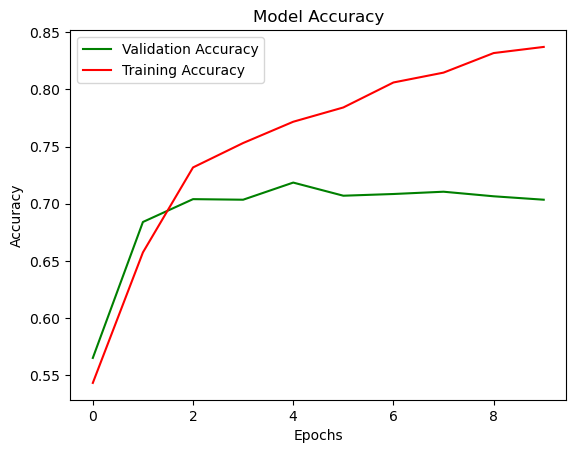


On remarque que l'accuracy de validation est moins bonne que l'accuracy d'entraînement, ce qui est bon signe : nous ne sommes pas en sur-apprentissage.

On remarque aussi qu'initialement, l'accuracy de validation augmente au fur et à mesure des epochs, ce qui est bon signe : le modèle apprend bien.

On remarque finalement que l'accuracy de validation devient stable à partir de la 3ème epoch, ce qui est bon signe : le modèle a appris et ne sur-apprend pas.
=> On peut donc arrêter l'entraînement ici au bout de 3 epochs pour éviter une perte de temps de calcul et un sur-apprentissage potentiel


In [180]:
# Visualisation des performances d'entraînement
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')  # Courbe de validation en vert
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')  # Courbe d'entraînement en rouge
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

print("\nOn remarque que l'accuracy de validation est moins bonne que l'accuracy d'entraînement, ce qui est bon signe : nous ne sommes pas en sur-apprentissage.")
print("\nOn remarque aussi qu'initialement, l'accuracy de validation augmente au fur et à mesure des epochs, ce qui est bon signe : le modèle apprend bien.")
print("\nOn remarque finalement que l'accuracy de validation devient stable à partir de la 3ème epoch, ce qui est bon signe : le modèle a appris et ne sur-apprend pas.\n=> On peut donc arrêter l'entraînement ici au bout de 3 epochs pour éviter une perte de temps de calcul et un sur-apprentissage potentiel")

### Nombre d'itérations pour obtenir une moyenne de la précision

In [181]:
num_iterations = 10

## MLP moyenné

Iteration 1/10
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5157 - loss: 0.6947 - val_accuracy: 0.5685 - val_loss: 0.6769
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.6300 - loss: 0.6437 - val_accuracy: 0.6855 - val_loss: 0.5337
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 0.7155 - loss: 0.4848 - val_accuracy: 0.7145 - val_loss: 0.4617
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.7517 - loss: 0.4319 - val_accuracy: 0.7035 - val_loss: 0.4555
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.7834 - loss: 0.4076 - val_accuracy: 0.7040 - val_loss: 0.4595
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.7979 - loss: 0.3807 - val_accuracy: 0.7060 - val_loss: 0.4619
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - accuracy: 0.8083 - loss: 0.3841 - val_accuracy: 0.7110 - val_loss: 0.4694
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.8219 - lo

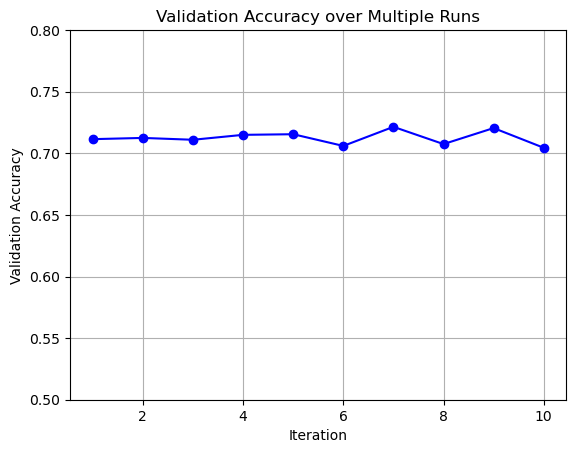

In [182]:
# Fonction de création du modèle de base
def create_model_base():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(50, activation='relu'),
        tf.keras.layers.Dense(25, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Lancer l'algorithme num_iterations fois et stocker les scores de validation accuracy
val_accuracies = []
for i in range(num_iterations):
    print(f'Iteration {i+1}/{num_iterations}')
    model = create_model_base()
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=1)
    val_acc = history.history['val_accuracy'][-1]  # Prendre la dernière valeur de la validation accuracy
    val_accuracies.append(val_acc)
    print(f'Validation Accuracy: {val_acc}\n')

# Calculer la moyenne de la validation accuracy
average_val_accuracy = np.mean(val_accuracies)
print(f'Average Validation Accuracy over {num_iterations} runs: {average_val_accuracy}')

# Tracer les résultats
plt.plot(range(1, num_iterations + 1), val_accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Iteration')
plt.ylabel('Validation Accuracy')
plt.ylim(0.5, 0.8)
plt.title('Validation Accuracy over Multiple Runs')
plt.grid(True)
plt.show()


## Introduction du Dropout

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5042 - loss: 0.7048 - val_accuracy: 0.5220 - val_loss: 0.6904
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5208 - loss: 0.6934 - val_accuracy: 0.5815 - val_loss: 0.6786
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.5754 - loss: 0.6715 - val_accuracy: 0.6660 - val_loss: 0.6141
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - accuracy: 0.6367 - loss: 0.6130 - val_accuracy: 0.7065 - val_loss: 0.4994
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.6813 - loss: 0.5326 - val_accuracy: 0.7135 - val_loss: 0.4625
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.6949 - loss: 0.4959 - val_accuracy: 0.7115 - val_loss: 0.4446
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.7118 - loss: 0.4665 - val_accuracy: 0.7175 - val_loss: 0.4390
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - accuracy: 0.7026 - loss: 0.4731 - val_

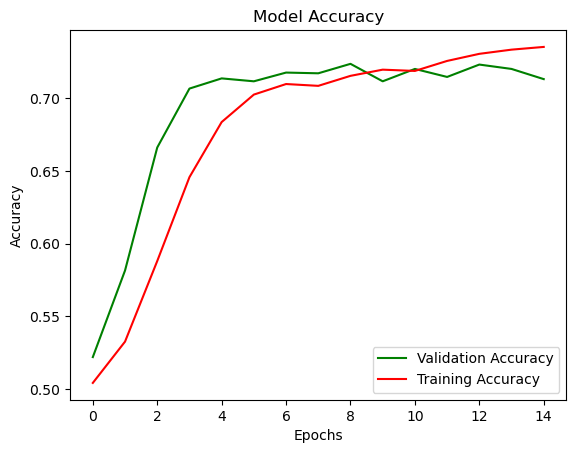


On remarque que l'accuracy de validation est moins bonne que l'accuracy d'entraînement, ce qui est bon signe : nous ne sommes pas en sur-apprentissage.

On remarque aussi qu'initialement, l'accuracy de validation augmente au fur et à mesure des epochs, ce qui est bon signe : le modèle apprend bien.

On remarque finalement que l'accuracy de validation devient stable à partir de la 6ème epoch, ce qui est bon signe : le modèle a appris et ne sur-apprend pas.
=> On peut donc arrêter l'entraînement ici au bout de 6 epochs pour éviter une perte de temps de calcul et un sur-apprentissage potentiel


In [183]:
# Fonction de création du modèle avec dropout
def create_model_dropout():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dropout(0.3),  # Dropout 30% pour régularisation
        tf.keras.layers.Dense(50, activation='relu'),
        tf.keras.layers.Dropout(0.3),  # Dropout 30% pour régularisation
        tf.keras.layers.Dense(25, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Entraînement du modèle avec dropout
model = create_model_dropout()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, verbose=1)

# Tracer les résultats
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

print("\nOn remarque que l'accuracy de validation est moins bonne que l'accuracy d'entraînement, ce qui est bon signe : nous ne sommes pas en sur-apprentissage.")
print("\nOn remarque aussi qu'initialement, l'accuracy de validation augmente au fur et à mesure des epochs, ce qui est bon signe : le modèle apprend bien.")
print("\nOn remarque finalement que l'accuracy de validation devient stable à partir de la 6ème epoch, ce qui est bon signe : le modèle a appris et ne sur-apprend pas.\n=> On peut donc arrêter l'entraînement ici au bout de 6 epochs pour éviter une perte de temps de calcul et un sur-apprentissage potentiel")

## Algorithme avec dropout moyenné

Iteration 1/10
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5159 - loss: 0.7079 - val_accuracy: 0.5445 - val_loss: 0.6881
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.5331 - loss: 0.6881 - val_accuracy: 0.5285 - val_loss: 0.6869
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.5462 - loss: 0.6857 - val_accuracy: 0.5875 - val_loss: 0.6711
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.5773 - loss: 0.6686 - val_accuracy: 0.6510 - val_loss: 0.6100
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - accuracy: 0.6312 - loss: 0.6199 - val_accuracy: 0.7115 - val_loss: 0.5078
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.6850 - loss: 0.5392 - val_accuracy: 0.7025 - val_loss: 0.4633
Validation Accuracy: 0.7024999856948853

Iteration 2/10
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5187 - loss: 0.7090 - val_accuracy: 0.5085 - val_loss: 0.6927
Epoch 2/6
250/250 ━━━━━━━━━━━━

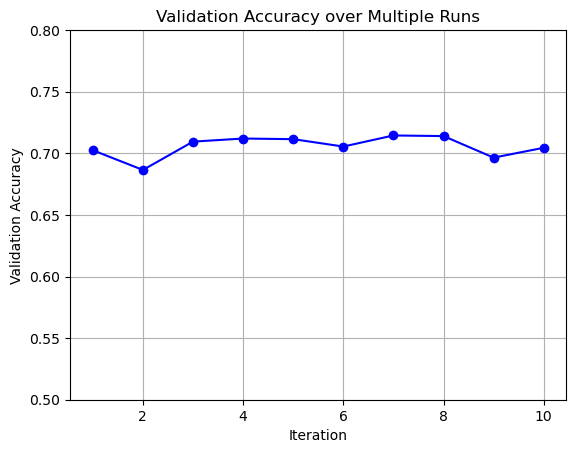

In [184]:
# Lancer l'algorithme num_iterations fois et stocker les scores de validation accuracy
val_accuracies = []
for i in range(num_iterations):
    print(f'Iteration {i+1}/{num_iterations}')
    model = create_model_dropout()  # Création du modèle avec dropout
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=6, verbose=1)
    val_acc = history.history['val_accuracy'][-1]  # Prendre la dernière valeur de la validation accuracy
    val_accuracies.append(val_acc)
    print(f'Validation Accuracy: {val_acc}\n')

# Calculer la moyenne de la validation accuracy
average_val_accuracy = np.mean(val_accuracies)
print(f'Average Validation Accuracy over {num_iterations} runs: {average_val_accuracy}')

# Tracer les résultats
plt.plot(range(1, num_iterations + 1), val_accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Iteration')
plt.ylabel('Validation Accuracy')
plt.ylim(0.5, 0.8)
plt.title('Validation Accuracy over Multiple Runs')
plt.grid(True)
plt.show()

## Graphique détermination meilleur rate de dropout

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5071 - loss: 0.7025 - val_accuracy: 0.5395 - val_loss: 0.6857
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.5715 - loss: 0.6750 - val_accuracy: 0.6070 - val_loss: 0.6500
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6516 - loss: 0.6052 - val_accuracy: 0.6965 - val_loss: 0.5087
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.7211 - loss: 0.4903 - val_accuracy: 0.7155 - val_loss: 0.4600
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.7278 - loss: 0.4534 - val_accuracy: 0.7235 - val_loss: 0.4454
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.7487 - loss: 0.4363 - val_accuracy: 0.7335 - val_loss: 0.4370
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - accuracy: 0.7566 - loss: 0.4255 - val_accuracy: 0.7250 - val_loss: 0.4435
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.7741 - loss: 0.4125 - val_accuracy: 0

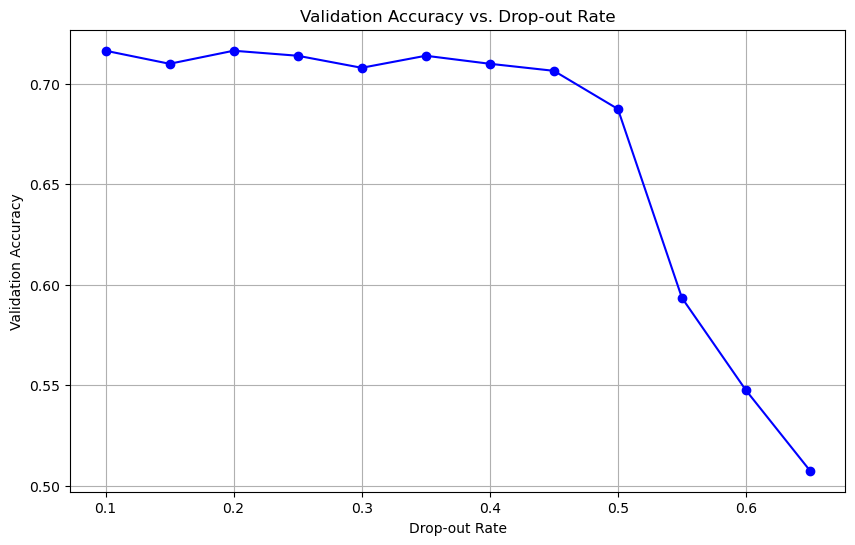

In [185]:
# Normaliser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Ajustement et transformation sur train
X_test = scaler.transform(X_test)  # Transformation uniquement sur test

# Initialiser les taux de dropout et les résultats
dropout_rates = np.arange(0.1,0.7,0.05)  # Taux de 0.1 à 0.7 par pas de 0.01
results = []

# Modèle de réseau neuronal avec taux de dropout variable
def create_model_rate(dropout_rate):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dropout(dropout_rate),  # Taux de dropout paramétrable
        tf.keras.layers.Dense(50, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),  # Même taux sur les deux couches
        tf.keras.layers.Dense(25, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Entraîner le modèle avec différents taux de dropout
for dropout_rate in dropout_rates:
    model = create_model_rate(dropout_rate)
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=1)
    val_accuracy = history.history['val_accuracy'][-1]  # Dernière epoch
    results.append(val_accuracy)
    print(f"Drop-out rate: {dropout_rate}, Validation Accuracy: {val_accuracy}")

# Créer le graphe
plt.figure(figsize=(10, 6))
plt.plot(dropout_rates, results, marker='o', linestyle='-', color='b')
plt.title('Validation Accuracy vs. Drop-out Rate')
plt.xlabel('Drop-out Rate')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()


Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4944 - loss: 0.7324 - val_accuracy: 0.5080 - val_loss: 0.6930
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5142 - loss: 0.6951 - val_accuracy: 0.5190 - val_loss: 0.6919
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5010 - loss: 0.6988 - val_accuracy: 0.5190 - val_loss: 0.6916
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4977 - loss: 0.6983 - val_accuracy: 0.5230 - val_loss: 0.6915
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5193 - loss: 0.6937 - val_accuracy: 0.5240 - val_loss: 0.6918
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5208 - loss: 0.6915 - val_accuracy: 0.5230 - val_loss: 0.6911
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5159 - loss: 0.6930 - val_accuracy: 0.5380 - val_loss: 0.6902
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5175 - loss: 0.6928 - val_accuracy: 0.5460 - val_loss:

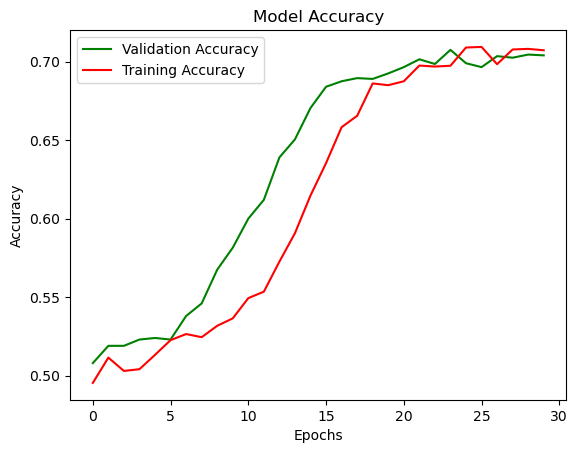

In [186]:
# Modèle final avec taux de dropout optimisé
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout à 50%
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout à 50%
    tf.keras.layers.Dense(25, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compilation du modèle
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entraînement avec batch_size et epochs augmentés
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=100, epochs=30, verbose=1)

# Visualisation des performances
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Diminution du batch_size

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5104 - loss: 0.7390 - val_accuracy: 0.4950 - val_loss: 0.6954
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.4973 - loss: 0.7008 - val_accuracy: 0.5070 - val_loss: 0.6941
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.5084 - loss: 0.6953 - val_accuracy: 0.5095 - val_loss: 0.6931
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - accuracy: 0.4969 - loss: 0.6968 - val_accuracy: 0.5065 - val_loss: 0.6931
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.5197 - loss: 0.6920 - val_accuracy: 0.5345 - val_loss: 0.6902
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.5187 - loss: 0.6906 - val_accuracy: 0.5575 - val_loss: 0.6873
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.5346 - loss: 0.6875 - val_accuracy: 0.5830 - val_loss: 0.6803
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.5564 - loss: 0.6797 - va

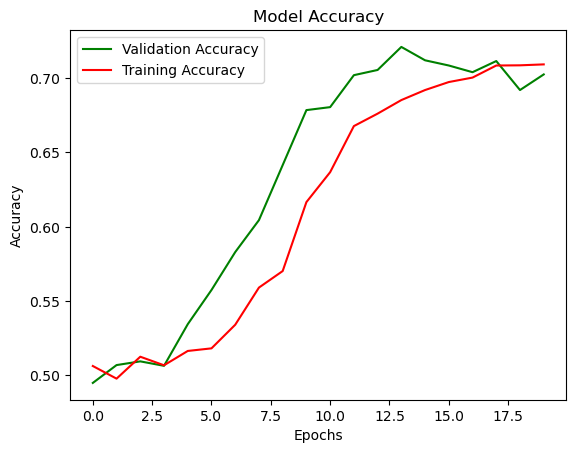

In [187]:
# Réseau de neurones pour classification binaire
model = tf.keras.Sequential([
tf.keras.layers.Dense(100, activation='relu'),    # 100 neurones, activation ReLU
tf.keras.layers.Dropout(0.5),                     # Dropout 50% contre le surapprentissage
tf.keras.layers.Dense(50, activation='relu'),     # 50 neurones, activation ReLU
tf.keras.layers.Dropout(0.5),                     # Dropout 50%
tf.keras.layers.Dense(25, activation='relu'),     # 25 neurones, activation ReLU
tf.keras.layers.Dense(1, activation='sigmoid')    # Sortie binaire (0-1)
])

# Compilation : perte binaire, optimiseur Adam
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entraînement 20 époques, batch 32
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=32, epochs=20, verbose=1)

# Graphique des performances
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Graphique détermination du meilleur batch_size

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5169 - loss: 0.7039 - val_accuracy: 0.5210 - val_loss: 0.6884
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.5346 - loss: 0.6874 - val_accuracy: 0.5980 - val_loss: 0.6563
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 637us/step - accuracy: 0.6074 - loss: 0.6346 - val_accuracy: 0.6795 - val_loss: 0.5148
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - accuracy: 0.6777 - loss: 0.5296 - val_accuracy: 0.7035 - val_loss: 0.4502
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.6975 - loss: 0.4893 - val_accuracy: 0.6845 - val_loss: 0.4497
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.7186 - loss: 0.4589 - val_accuracy: 0.7090 - val_loss: 0.4383
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 647us/step - accuracy: 0.7151 - loss: 0.4555 - val_accuracy: 0.7105 - val_loss: 0.4367
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.7186 - loss: 0.4544 - val_accuracy:

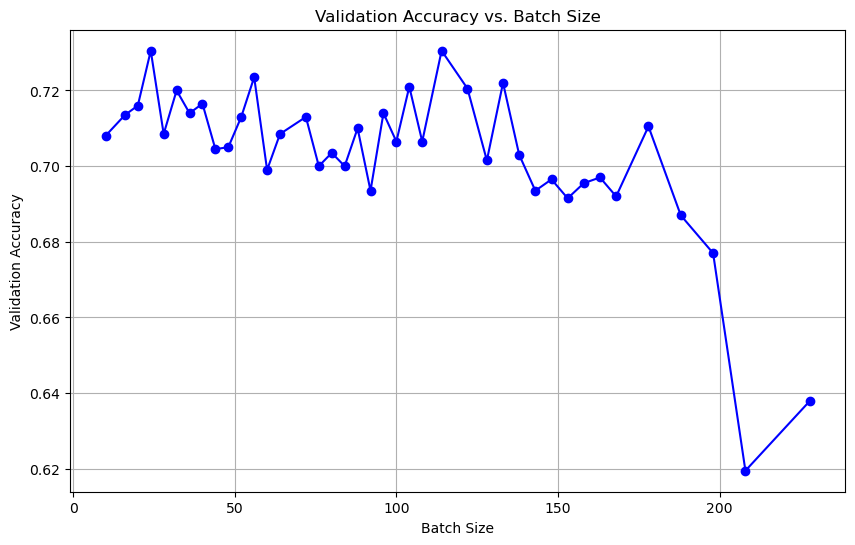

In [188]:
# Normaliser les données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Liste des batch sizes à tester
batch_sizes = [10,16,20,24,28,32,36,40,44,48,52,56,60,64,72,76,80,84,88,92,96,100,104,108,114,122,128,133,138,143,148,153,158,163,168,178,188,198,208,228]
results = []

# Fonction pour créer le modèle
def create_model_batch_size():
   model = tf.keras.Sequential([
       tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train.shape[1],)),  # Couche d'entrée
       tf.keras.layers.Dropout(0.3),                                                    # Dropout 30%
       tf.keras.layers.Dense(50, activation='relu'),                                    # Couche cachée
       tf.keras.layers.Dropout(0.3),                                                    # Dropout 30%
       tf.keras.layers.Dense(25, activation='relu'),                                    # Couche cachée
       tf.keras.layers.Dense(1, activation='sigmoid')                                   # Sortie binaire
   ])
   model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
   return model

# Test de chaque batch size
for batch_size in batch_sizes:
   model = create_model_batch_size()
   history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                      batch_size=batch_size, epochs=10, verbose=1)
   val_accuracy = history.history['val_accuracy'][-1]  # Récupère la dernière accuracy
   results.append(val_accuracy)
   print(f"Batch size: {batch_size}, Validation Accuracy: {val_accuracy}")

# Graphique des résultats
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, results, marker='o', linestyle='-', color='b')
plt.title('Validation Accuracy vs. Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()


# Réseau de neurones récurrents

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5103 - loss: 0.6936 - val_accuracy: 0.5440 - val_loss: 0.6915
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5406 - loss: 0.6875 - val_accuracy: 0.5965 - val_loss: 0.6642
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6136 - loss: 0.6368 - val_accuracy: 0.6770 - val_loss: 0.5285
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6906 - loss: 0.5127 - val_accuracy: 0.7110 - val_loss: 0.4733
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7197 - loss: 0.4722 - val_accuracy: 0.6970 - val_loss: 0.4732
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7309 - loss: 0.4492 - val_accuracy: 0.7115 - val_loss: 0.4612
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7410 - loss: 0.4425 - val_accuracy: 0.6940 - val_loss: 0.4604
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7529 - loss: 0.4291 - val_accuracy: 0.7015 - val_

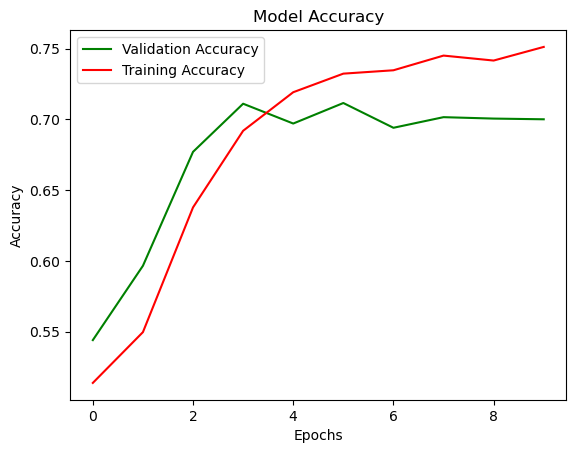

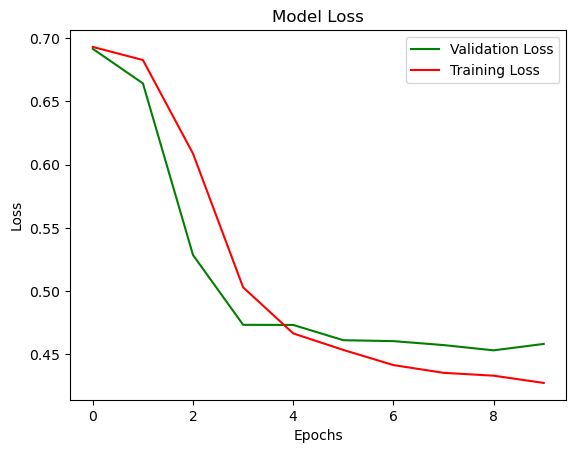

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Final accuracy score: 0.7


In [189]:
# Préparation des données
y = df['player_1_win']                              # Variable cible
X = df.drop(["player_1_win"], axis = 1)             # Variables explicatives
scaler = StandardScaler()
X = scaler.fit_transform(X)                         # Normalisation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Reshape pour LSTM (tenseur 3D requis)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)
input_shape = (X_train.shape[1], X_train.shape[2])

# Modèle RNN avec LSTM
def create_model_RNN():
   model = tf.keras.Sequential([
       tf.keras.layers.LSTM(100, activation='relu', input_shape=input_shape),  # Couche LSTM
       tf.keras.layers.Dropout(0.3),                                           # Dropout 30%
       tf.keras.layers.Dense(50, activation='relu'),                           # Couche dense
       tf.keras.layers.Dropout(0.3),                                           # Dropout 30%
       tf.keras.layers.Dense(25, activation='relu'),                           # Couche dense
       tf.keras.layers.Dense(1, activation='sigmoid')                          # Sortie binaire
   ])
   model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
   return model

model = create_model_RNN()

# Entraînement
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                  batch_size=32, epochs=10, verbose=1)

# Graphiques de performance
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['val_loss'], c="green", label='Validation Loss')
plt.plot(history.history['loss'], c='red', label='Training Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Évaluation finale
y_hat = (model.predict(X_test) > 0.5).astype("int32")  # Prédictions binaires
print(f'Final accuracy score: {accuracy_score(y_test, y_hat)}')

## RNN moyenné

In [190]:
# Préparation des données
y = df['player_1_win']                              # Variable cible
X = df.drop(["player_1_win"], axis = 1)             # Variables explicatives
scaler = StandardScaler()
X = scaler.fit_transform(X)                         # Normalisation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Reshape pour LSTM (tenseur 3D)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

# Test de stabilité sur plusieurs itérations
val_accuracies = []
for i in range(num_iterations):
   print(f'Iteration {i+1}/{num_iterations}')
   model = create_model_RNN()
   history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                      batch_size=32, epochs=10, verbose=1)
   val_acc = history.history['val_accuracy'][-1]   # Dernière accuracy de validation
   val_accuracies.append(val_acc)
   print(f'Validation Accuracy: {val_acc}\n')

# Calcul de la moyenne
average_val_accuracy = np.mean(val_accuracies)
print(f'Average Validation Accuracy over {num_iterations} runs: {average_val_accuracy}')


Iteration 1/10
Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5105 - loss: 0.6935 - val_accuracy: 0.5365 - val_loss: 0.6879
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5748 - loss: 0.6766 - val_accuracy: 0.6660 - val_loss: 0.5728
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6634 - loss: 0.5579 - val_accuracy: 0.7115 - val_loss: 0.4589
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7007 - loss: 0.4786 - val_accuracy: 0.7195 - val_loss: 0.4418
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7170 - loss: 0.4617 - val_accuracy: 0.7210 - val_loss: 0.4371
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7237 - loss: 0.4528 - val_accuracy: 0.7190 - val_loss: 0.4355
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7275 - loss: 0.4453 - val_accuracy: 0.7115 - val_loss: 0.4392
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7317 - loss: 0.4426 - val_accuracy: 0.7145 - val_

# Réseau de convolution

39


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_491"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 38, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 19, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_663 (Dropout)           │ (None, 19, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 18, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_664 (Dropout)           │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1951 (Dense)              │ (None, 128)            │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1952 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_665 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1953 (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,489 (185.50 KB)

 Trainable params: 47,489 (185.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4982 - loss: 0.7008 - val_accuracy: 0.5175 - val_loss: 0.6923
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5089 - loss: 0.6933 - val_accuracy: 0.5095 - val_loss: 0.6929
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5033 - loss: 0.6937 - val_accuracy: 0.5115 - val_loss: 0.6928
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5033 - loss: 0.6937 - val_accuracy: 0.5045 - val_loss: 0.6928
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5081 - loss: 0.6929 - val_accuracy: 0.5055 - val_loss: 0.6924
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5116 - loss: 0.6926 - val_accuracy: 0.5220 - val_loss: 0.6918
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5258 - loss: 0.6915 - val_accuracy: 0.5015 - val_loss: 0.6915
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5159 - loss: 0.6925 - val_accuracy: 0.

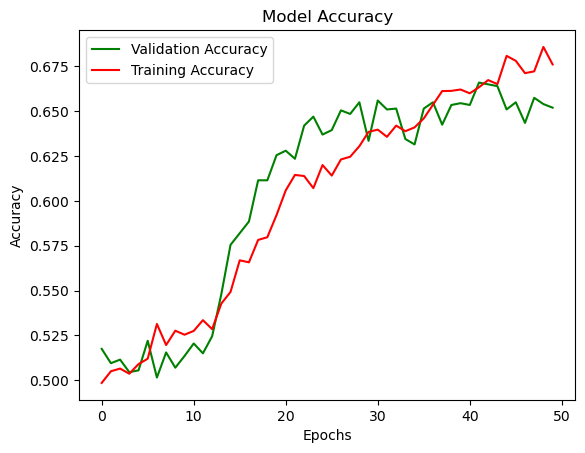

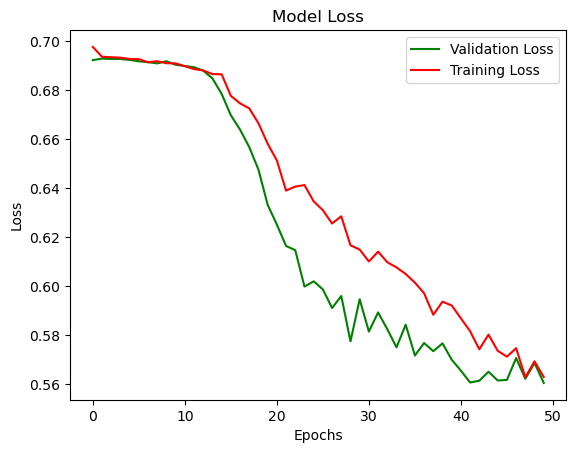

In [191]:
# Préparation des données
X = df.drop(["player_1_win"], axis = 1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)                  # Normalisation
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape[1])

# Reshape pour CNN 1D (ajout dimension canal)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
input_shape = (X_train_cnn.shape[1], 1)

# Modèle CNN 1D
def create_model_CNN():
   model = tf.keras.Sequential()
   model.add(tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu', input_shape=input_shape))  # Conv1D 32 filtres
   model.add(tf.keras.layers.MaxPooling1D(pool_size=2))                                              # Max pooling
   model.add(tf.keras.layers.Dropout(0.3))                                                           # Dropout 30%
   model.add(tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu'))                          # Conv1D 32 filtres
   model.add(tf.keras.layers.MaxPooling1D(pool_size=2))                                              # Max pooling
   model.add(tf.keras.layers.Dropout(0.3))                                                           # Dropout 30%
   model.add(tf.keras.layers.Flatten())                                                              # Aplatissement
   model.add(tf.keras.layers.Dense(128, activation='relu'))                                          # Dense 128
   model.add(tf.keras.layers.Dense(64, activation='relu'))                                           # Dense 64
   model.add(tf.keras.layers.Dropout(0.5))                                                           # Dropout 50%
   model.add(tf.keras.layers.Dense(1, activation='sigmoid'))                                         # Sortie binaire
   model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
   return model

model = create_model_CNN()
model.summary()

# Entraînement sur 50 époques
history = model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_data=(X_test_cnn, y_test))

# Évaluation finale
loss, accuracy = model.evaluate(X_test_cnn, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

# Graphiques de performance
plt.plot(history.history['val_accuracy'], c="green", label='Validation Accuracy')
plt.plot(history.history['accuracy'], c='red', label='Training Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['val_loss'], c="green", label='Validation Loss')
plt.plot(history.history['loss'], c='red', label='Training Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Comparaisons

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5001 - loss: 0.7116 - val_accuracy: 0.5160 - val_loss: 0.6928
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.5220 - loss: 0.6911 - val_accuracy: 0.5320 - val_loss: 0.6884
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - accuracy: 0.5303 - loss: 0.6885 - val_accuracy: 0.5460 - val_loss: 0.6776
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.5702 - loss: 0.6739 - val_accuracy: 0.6200 - val_loss: 0.6408
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.6300 - loss: 0.6273 - val_accuracy: 0.6740 - val_loss: 0.5477
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.6766 - loss: 0.5494 - val_accuracy: 0.6820 - val_loss: 0.4897
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.7045 - loss: 0.4940 - val_accuracy: 0.6915 - val_loss: 0.4670
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.7088 - loss: 0.4712 - val_accuracy:

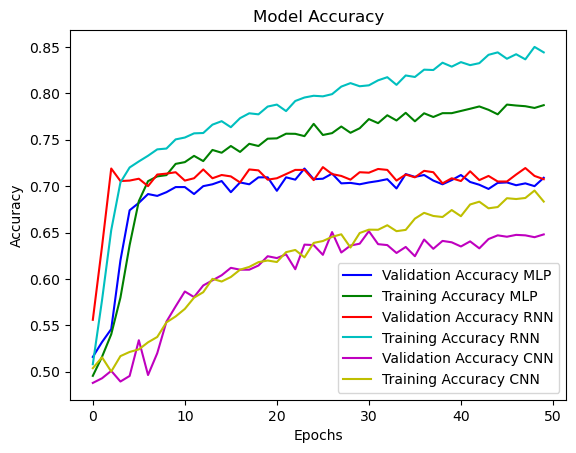

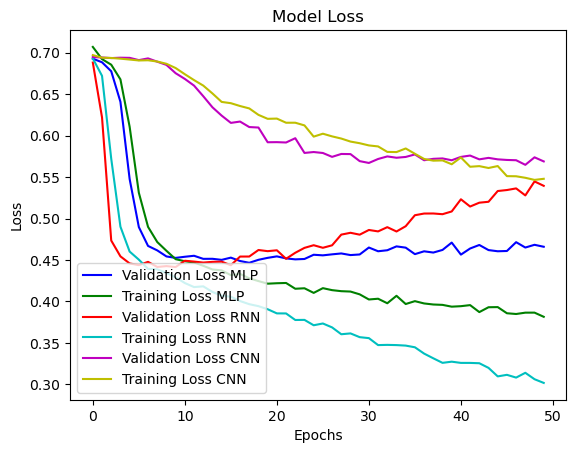

In [192]:
# Préparation données MLP
y = df['player_1_win']                              # Variable cible
X = df.drop(["player_1_win"], axis = 1)             # Variables explicatives
scaler = StandardScaler()
X = scaler.fit_transform(X)                         # Normalisation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model_MLP = create_model_dropout()

# Préparation données RNN
y = df['player_1_win'] 
X = df.drop(["player_1_win"], axis = 1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_RNN = np.expand_dims(X_train, axis=1)       # Reshape pour RNN
X_test_RNN = np.expand_dims(X_test, axis=1)
input_shape = (X_train_RNN.shape[1], X_test_RNN.shape[2])
model_RNN = create_model_RNN()

# Préparation données CNN
X = df.drop(["player_1_win"], axis = 1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)  # Reshape pour CNN
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
input_shape = (X_train_cnn.shape[1], 1)
model_CNN = create_model_CNN()

# Entraînement des 3 modèles
history_MLP = model_MLP.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

y = df['player_1_win']
X = df.drop(["player_1_win"], axis = 1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_RNN = np.expand_dims(X_train, axis=1)
X_test_RNN = np.expand_dims(X_test, axis=1)
input_shape = (X_train_RNN.shape[1], X_test_RNN.shape[2])
history_RNN = model_RNN.fit(X_train_RNN, y_train, epochs=50, batch_size=32, validation_data=(X_test_RNN, y_test))

X = df.drop(["player_1_win"], axis = 1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
input_shape = (X_train_cnn.shape[1], 1)
history_CNN = model_CNN.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_data=(X_test_cnn, y_test))

# Comparaison des accuracies
plt.plot(history_MLP.history['val_accuracy'], c="b", label='Validation Accuracy MLP')
plt.plot(history_MLP.history['accuracy'], c='g', label='Training Accuracy MLP')
plt.plot(history_RNN.history['val_accuracy'], c="r", label='Validation Accuracy RNN')
plt.plot(history_RNN.history['accuracy'], c='c', label='Training Accuracy RNN')
plt.plot(history_CNN.history['val_accuracy'], c="m", label='Validation Accuracy CNN')
plt.plot(history_CNN.history['accuracy'], c='y', label='Training Accuracy CNN')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Comparaison des losses
plt.plot(history_MLP.history['val_loss'], c="b", label='Validation Loss MLP')
plt.plot(history_MLP.history['loss'], c='g', label='Training Loss MLP')
plt.plot(history_RNN.history['val_loss'], c="r", label='Validation Loss RNN')
plt.plot(history_RNN.history['loss'], c='c', label='Training Loss RNN')
plt.plot(history_CNN.history['val_loss'], c="m", label='Validation Loss CNN')
plt.plot(history_CNN.history['loss'], c='y', label='Training Loss CNN')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()